# Variogram Model  


Here we fit a variogram model to the experimental variogram calculated in the Experimental_Variogram example. Why fit a parametric variogram model to the experimental variogram? First of all, we need a way to interpolate variance estimates to all lag distances. Second, a variogram must satisfy certain mathematical properties in order to be used in kriging and stochastic simulation. This is covered in the Simple_Kriging.ipynb notebook.

The parameters of a variogram model are the nugget, sill, and range. The nugget or y-intercept represents small scale variability. Some of the nugget effect could be attributed to measurement error. The range is the lag distance where the variogram levels off. This means that two points separated by a lag distance greater than or equal to the range are not spatially correlated. The sill is the maximum variability between two points. When working with data that has been transformed to a standard Gaussian distribution, the sill is approximately 1. 


:::{figure-md} markdown-fig
<img src="./Images/variogram.png" class="bg-primary mb-1" width="500px">

Variogram schematic
:::

We use the SciKit-GStat package to model our variograms (see https://scikit-gstat.readthedocs.io/en/latest/ for more details).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.preprocessing import QuantileTransformer 
import skgstat as skg
from skgstat import models
import gstatsim as gs
import geopandas as gpd
from plot_utils import splot2D
import pyogrio
from shapely import make_valid as shp_make_valid

## Load and plot data

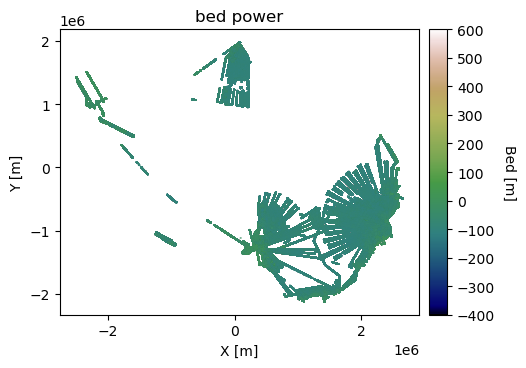

In [26]:
# importing icethk data 
gdf = gpd.read_parquet("data/icethk_all.parquet")
bpow = gdf[['X', 'Y', 'BED_REFLECT']]
splot2D(df=bpow, title='bed power', c='BED_REFLECT')

My new data is large! I will clip to a smaller, more densely sampled area for this example.

In [27]:
wilkes = pyogrio.read_dataframe("data/WilkesLand/WilkesLand.shp", force_2d=True, on_invalid="fix")
wilkes["geometry"] = wilkes.geometry.apply(shp_make_valid)
wilkes = wilkes.set_crs("EPSG:3031").to_crs(gdf.crs)

In [28]:
#clipping to wilkesland
# Clip data to WilkesLand boundary (wilkes already loaded and reprojected above)
gdf = gpd.clip(gdf, wilkes)
print(f"Points after clipping: {len(gdf)}")

Points after clipping: 3539604


In [29]:
gdf=gdf.dropna()
print(f"Points after clipping: {len(gdf)}")

Points after clipping: 1590497


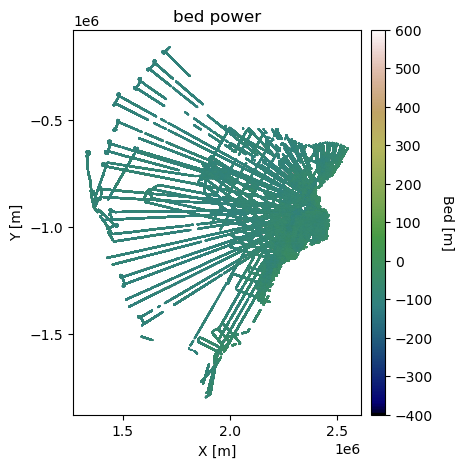

In [35]:
splot2D(df=gdf, title='bed power', c='BED_REFLECT')

In [30]:
#ok now randomly sampling 1% of my data to form the variogram which speeds it up for the purpose of this example

df_sample = gdf.sample(frac=0.01, random_state=42)

## Normal score transformation and experimental variogram

3158074    0.907921
4333657   -0.255256
4663109   -1.587574
104084     0.181836
3395486   -0.026124
             ...   
2497829   -0.885920
180493     1.049186
2615533   -0.655871
5588774    1.748763
300379    -0.720133
Name: BED_REFLECT, Length: 15905, dtype: float64


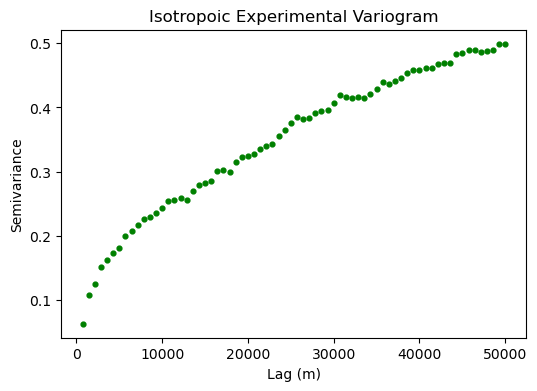

In [31]:

# normal score transformation
data = df_sample['BED_REFLECT'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(data)
df_sample['BED_REFLECT'] = nst_trans.transform(data) 

# compute experimental (isotropic) variogram
coords = df_sample[['X','Y']].values
values = df_sample['BED_REFLECT']
print(values)
maxlag = 50000          # maximum range distance
n_lags = 70             # num of bins

# compute variogram
V1 = skg.Variogram(coords, values, bin_func='even', n_lags=n_lags, 
                   maxlag=maxlag, normalize=False)

# extract variogram values
xdata = V1.bins
ydata = V1.experimental

plt.figure(figsize=(6,4))
plt.scatter(xdata, ydata, s=12, c='g')
plt.title('Isotropoic Experimental Variogram')
plt.xlabel('Lag (m)'); plt.ylabel('Semivariance')  
plt.show()

## Fit variogram model

The variogram parameters are determined automatically using the SciKit-GStat functions:

In [32]:
# use exponential variogram model
V1.model = 'matern' 
V1.parameters

[np.float64(49999.98868381904),
 np.float64(0.4971861454629785),
 np.float64(0.35569236491207584),
 0]

These values are the range, sill, and nugget, respectively. The range describes the correlation length, or distance where two measurements are no longer correlated The sill is variance where the range is reached. The nugget is the variance at a lag distance of zero. 

The nugget effect is often attributed to measurement error (i.e., a non-zero nugget results from measurements with different values at the same location). We have a nugget of zero because our data is gridded. Depending on the analysis, it can be useful to work with non-gridded data in order to investigate the nugget effect and measurement uncertainty. For certain interpolation problems, it is best to have a nugget of zero, while sometimes it is useful to include the nugget.

Now we will create the variogram model. While there are many different variogram model types (see SCiKit-GStat documentation), GStatSim uses the exponential variogram model, which is the most widely used:

$$
\gamma(h) = b + (c - b)[1 - exp^{(-\frac{3h}{a})}]
$$


where $b$ is the nugget, $h$ is the lag distance, $c$ is the sill, and $a$ is the range. Note that the SCiKit-GStat variogram modeling defaults assign a nugget of 0.

In [33]:
# set variogram parameters
vrange = V1.parameters[0]
vsill = V1.parameters[1]
vnugget = V1.parameters[2]

# evaluate models
xi = np.linspace(0, xdata[-1], 1000) 
y_exp = [models.matern(h, vrange, vsill, vnugget) for h in xi]

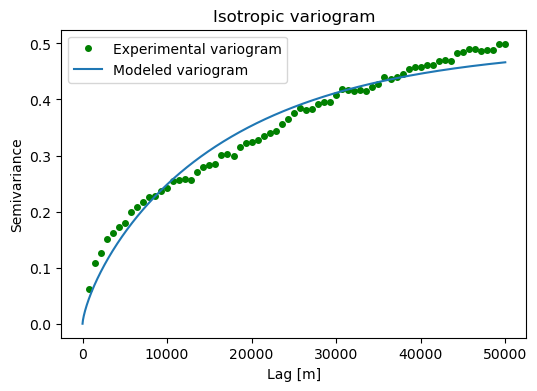

In [34]:
# plot variogram model
plt.figure(figsize=(6,4))
plt.plot(xdata, ydata,'og', markersize=4, label='Experimental variogram')
plt.plot(xi, y_exp,'-', label='Modeled variogram')
plt.title('Isotropic variogram')
plt.xlabel('Lag [m]'); plt.ylabel('Semivariance')  
plt.legend(loc='upper left')
plt.show()

For anisotropic variograms, the variogram should be modeled in the major (smoothest) and minor (roughest) directions, which are typicaly orthogonal to each other.

Now that the variogram is modeled, we can use this information to perform interpolations.

Download the tutorial {Download}`here<./2_Variogram_model.ipynb>`.